In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

In [2]:
file_path = r"D:\7_Research\3_projects\20250104_MacaqueHuman\Results\Materials_for_publication\Data\connections"
# read inferred directionality matrix
directional_mat_l = pd.read_csv(f"{file_path}/DirectionalConnectome_D99_HCPex_left_dens20.csv", index_col=0)
directional_mat_r = pd.read_csv(f"{file_path}/DirectionalConnectome_D99_HCPex_right_dens20.csv", index_col=0)
# read connectivity matrix
connectivity_mat = pd.read_csv(f"{file_path}/DWI_connectivity_HCP-YA100_streamline.csv", index_col=0)
directional_mat_l = directional_mat_l.values
directional_mat_r = directional_mat_r.values
connectivity_mat = connectivity_mat.values

In [3]:
# reorder the connectivity matrix according to the order of the directional matrices
arr = connectivity_mat  
rows_part1 = arr[:180, :]       
rows_part2 = arr[360:393, :]    
rows_part3 = arr[180:360, :]    
rows_part4 = arr[393:426, :]    
selected_rows = np.vstack((rows_part1, rows_part2, rows_part3, rows_part4))  

cols_part1 = selected_rows[:, :180]      
cols_part2 = selected_rows[:, 360:393]  
cols_part3 = selected_rows[:, 180:360]  
cols_part4 = selected_rows[:, 393:426]  
connectivity_mat_order = np.hstack((cols_part1, cols_part2, cols_part3, cols_part4)) 

# scale the connectivity matrix using log10
connectivity_mat_order = np.log10(connectivity_mat_order+1)

# split the connectivity matrix into left and right hemisphere
connectivity_mat_left = connectivity_mat_order[:213, :213]
connectivity_mat_right = connectivity_mat_order[213:, 213:]

In [4]:
# Optional process, balace the Information form directional inferring matrix and tractography part in the final connectome.
# in this study, we add top 15% conntion from tractography in subcortical regions to the final connectome, due to lack of subcortical connections in the directional inferring matrix.
# suppose a1, a2, b, c are the weight of bi-directional, uni-directional and keep part in the final connectome
def mat_generater(tract_mat, diection_mat, a1, a2, b, c):
    upper_tri = np.triu(diection_mat, k=1)
    lower_tri = np.tril(diection_mat, k=-1)
    M_mask = diection_mat + diection_mat.T
    M_mask = (M_mask == 0)
    M_mask = M_mask.astype(int)
    asymmetric_indices = np.where(upper_tri != lower_tri.T)
    asymmetric_values_upper = upper_tri[asymmetric_indices]
    convince_indices = np.where((upper_tri == 1) & (lower_tri.T == 1))
    # calcualte the fix part of connectome
    M_t_bi = np.zeros(tract_mat.shape)
    M_t_bi[convince_indices] = tract_mat[convince_indices]
    M_t_bi[convince_indices[1],convince_indices[0]] = tract_mat[convince_indices[1],convince_indices[0]]
    M_t_uni = np.zeros(tract_mat.shape)
    for i in range(len(asymmetric_values_upper)):
        if asymmetric_values_upper[i] == 1:
            M_t_uni[asymmetric_indices[0][i],asymmetric_indices[1][i]] = tract_mat[asymmetric_indices[0][i],asymmetric_indices[1][i]] 
        else:
            M_t_uni[asymmetric_indices[1][i],asymmetric_indices[0][i]] = tract_mat[asymmetric_indices[0][i],asymmetric_indices[1][i]]

    # trust c*100 % connection in the connectivity matrix
    rank_track = tract_mat.flatten()
    rank_track = np.sort(rank_track)
    rank_track = rank_track[rank_track >0]
    if c == 0:
        M_t_keep = np.zeros(tract_mat.shape)
    if c > 0:
        threshold = rank_track[int(len(rank_track)*(1-c))]
        M_t_keep = tract_mat.copy()
        M_t_keep[M_t_keep<threshold] = 0
        M_t_keep = M_t_keep * M_mask
    M_integrate = a1 * M_t_bi + a2 * M_t_uni + b * M_t_keep
    
    return M_integrate

In [5]:
connectivity_inferr_left = mat_generater(connectivity_mat_left, directional_mat_l, 0.9, 0.8, 0.8, 0.15)
connectivity_inferr_right = mat_generater(connectivity_mat_right, directional_mat_r, 0.9, 0.8, 0.8, 0.15)
connectivity_inferr_left[connectivity_inferr_left > 0] = 1
connectivity_inferr_left[180:213, :180] = 0
connectivity_inferr_left[:180, 180:213] = 0
connectivity_inferr_left[:180, :180] = 0
connectivity_inferr_left = connectivity_inferr_left + directional_mat_l
connectivity_inferr_left[connectivity_inferr_left > 0] = 1
# get the final connectome by adding the directional inferring matrix and the connectivity matrix
connectivity_inferr_left = mat_generater(connectivity_mat_left, connectivity_inferr_left, 1, 1, 0.8, 0)

In [6]:
mask = np.zeros(connectivity_inferr_left.shape)
mask[connectivity_inferr_left > 0] = 1
diff = directional_mat_l - mask

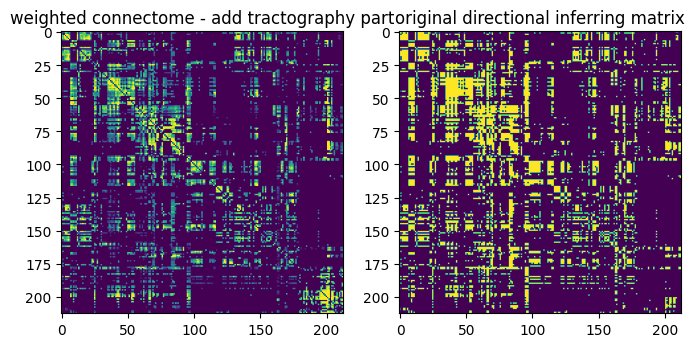

In [7]:
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(8, 4))
max_value = 1
camp = plt.cm.viridis

im0 = axs[0].imshow(connectivity_inferr_left, vmin=0, vmax=3 , cmap=camp)
axs[0].set_title("weighted connectome - add tractography part")

im0 = axs[1].imshow(directional_mat_l, vmin=0, vmax=1 , cmap=camp)
axs[1].set_title("original directional inferring matrix")

connectivity_mat_left
plt.show()

In [8]:
connectivity_inferr_right[connectivity_inferr_right> 0] = 1
connectivity_inferr_right[180:213, :180] = 0
connectivity_inferr_right[:180, 180:213] = 0
connectivity_inferr_right[:180, :180] = 0
connectivity_inferr_right = connectivity_inferr_right + directional_mat_r
connectivity_inferr_right[connectivity_inferr_right> 0] = 1
connectivity_inferr_right = mat_generater(connectivity_mat_right, connectivity_inferr_right, 1, 1, 0.8, 0)

In [9]:
mask = np.zeros(connectivity_inferr_right.shape)
mask[connectivity_inferr_right > 0] = 1
diff = directional_mat_r - mask

Text(0.5, 1.0, 'right hemisphere')

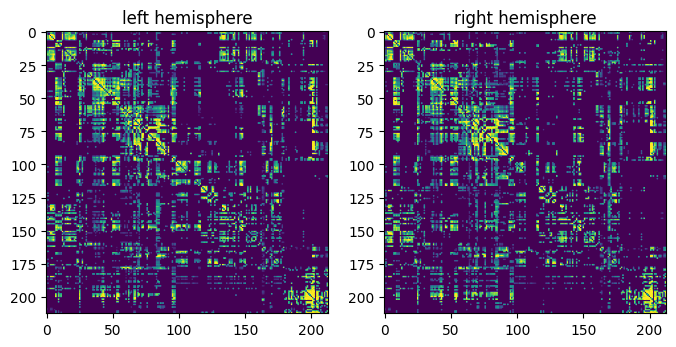

In [10]:
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(8, 4))
max_value = 1
camp = plt.cm.viridis

im0 = axs[0].imshow(connectivity_inferr_left, vmin=0, vmax=3 , cmap=camp)
axs[0].set_title("left hemisphere")

im0 = axs[1].imshow(connectivity_inferr_right, vmin=0, vmax=3 , cmap=camp)
axs[1].set_title("right hemisphere")


In [11]:
# keep top 10% connection in the tractography part as corss-hemisphere connection in the final connectome
c = 0.10
tract_mat = connectivity_mat_order
rank_track = tract_mat.flatten()
rank_track = np.sort(rank_track)
rank_track = rank_track[rank_track >0]
threshold = rank_track[int(len(rank_track)*(1-c))]
connectivity_keep = tract_mat.copy()
connectivity_keep[connectivity_keep<threshold] = 0

directional_mat = directional_mat_l + directional_mat_r
directional_mat[directional_mat > 0] = 1

directional_mat_corss_mask = np.zeros(directional_mat.shape)
directional_mat_corss_mask[180:213, :180] = directional_mat[180:213, :180]
directional_mat_corss_mask[:180, 180:213] = directional_mat[:180, 180:213]
directional_mat_corss_mask[:180, :180] = 1
directional_mat_corss_mask[180:, 180:] = 1

connectivity_keep[:213, 213:] = connectivity_keep[:213, 213:] * directional_mat_corss_mask[:213, :213]
connectivity_keep[213:, :213] = connectivity_keep[213:, :213] * directional_mat_corss_mask[:213, :213]

connectivity_inferr_whole = np.zeros((426,426))
connectivity_inferr_whole[:213,:213] = connectivity_inferr_left
connectivity_inferr_whole[213:,213:] = connectivity_inferr_right
connectivity_inferr_whole[:213,213:] = connectivity_keep[0:213, 213:] * 1
connectivity_inferr_whole[213:,:213] = connectivity_keep[213:, 0:213] * 1

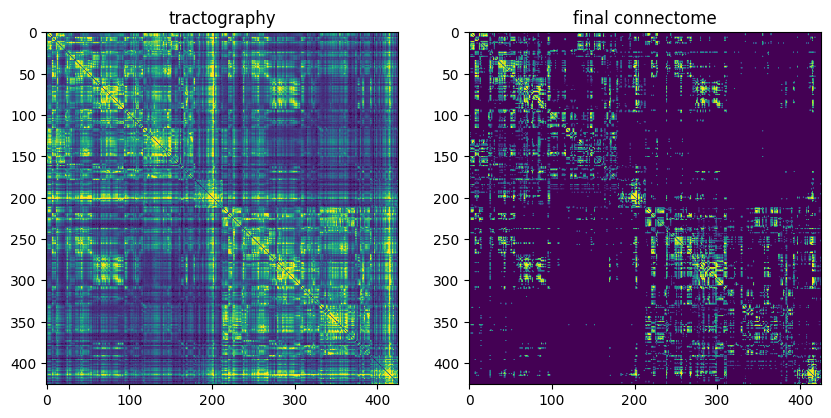

In [12]:
# show tractography and the final connectome
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(10, 5))
max_value = 1
camp = plt.cm.viridis

im0 = axs[0].imshow(connectivity_mat_order, vmin=0, vmax=3 , cmap=camp)
axs[0].set_title("tractography")

im0 = axs[1].imshow(connectivity_inferr_whole, vmin=0, vmax=3 , cmap=camp)
axs[1].set_title("final connectome")

plt.show()